In [21]:
from statistics import mean
from statistics import stdev
import pandas as pd
import pandasql as ps
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from prettytable import PrettyTable
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf
import seaborn as sns
from scipy.stats import poisson
from datetime import datetime

In [22]:
# df_1_layer = pd.read_csv('data/NA_hyperexpo/Output_with_layers_1.csv')
# df_2_layer = pd.read_csv('data/NA_hyperexpo/Output_with_layers_2.csv')
# df_3_layer = pd.read_csv('data/NA_hyperexpo/Output_with_layers_3.csv')
# df_4_layer = pd.read_csv('data/NA_hyperexpo/Output_with_layers_4.csv')
df_1_layer = pd.read_csv('data/Output_with_layers_1.csv')
df_2_layer = pd.read_csv('data/Output_with_layers_2.csv')
df_3_layer = pd.read_csv('data/Output_with_layers_3.csv')
df_4_layer = pd.read_csv('data/Output_with_layers_4.csv')

df_1_layer['timestamp'] -= 62168450400
df_1_layer['median_time'] = pd.to_datetime(df_1_layer['timestamp'], unit='s')
df_2_layer['timestamp'] -= 62168450400
df_2_layer['median_time'] = pd.to_datetime(df_2_layer['timestamp'], unit='s')
df_3_layer['timestamp'] -= 62168450400
df_3_layer['median_time'] = pd.to_datetime(df_3_layer['timestamp'], unit='s')
df_4_layer['timestamp'] -= 62168450400
df_4_layer['median_time'] = pd.to_datetime(df_4_layer['timestamp'], unit='s')

/var/folders/01/yhhv1lg93rnbyyq7g5q5pn1r0000gn/T/ipykernel_1332/915796210.py:5: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df_1_layer = pd.read_csv('data/Output_with_layers_1.csv')
/var/folders/01/yhhv1lg93rnbyyq7g5q5pn1r0000gn/T/ipykernel_1332/915796210.py:6: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df_2_layer = pd.read_csv('data/Output_with_layers_2.csv')
/var/folders/01/yhhv1lg93rnbyyq7g5q5pn1r0000gn/T/ipykernel_1332/915796210.py:7: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df_3_layer = pd.read_csv('data/Output_with_layers_3.csv')
/var/folders/01/yhhv1lg93rnbyyq7g5q5pn1r0000gn/T/ipykernel_1332/915796210.py:8: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df_4_layer = pd.read_csv('data/Output_with_layers_4.csv')


### Block times

In [23]:
import pandas as pd

# === Summary Stats ===
for i, df in enumerate([df_1_layer, df_2_layer, df_3_layer, df_4_layer], 1):
    print(f"with {i} layer{'s' if i > 1 else ''}:")
    print("mean:", df['block_time'].mean())
    print("stdev:", df['block_time'].std())

# === Sanity Check ===
for df in [df_1_layer, df_2_layer, df_3_layer, df_4_layer]:
    df['secondary_block_time'] = pd.to_datetime(df['median_time']).diff().dt.total_seconds().fillna(0)

print(df_1_layer['block_time'][1:].equals(df_1_layer['secondary_block_time'][1:]))
print(df_2_layer['block_time'][1:].equals(df_2_layer['secondary_block_time'][1:]))
print(df_3_layer['block_time'][1:].equals(df_3_layer['secondary_block_time'][1:]))
print(df_4_layer['block_time'][1:].equals(df_4_layer['secondary_block_time'][1:]))

# === Average Block Time per Day ===
def avg_block_time_per_day(df):
    df['median_time'] = pd.to_datetime(df['median_time'])
    df['day'] = df['median_time'].dt.floor('D')
    return df.groupby('day')['block_time'].mean().reset_index(name='avg_block_time')

q_res_1_layer_avg_block_time = avg_block_time_per_day(df_1_layer)
q_res_2_layer_avg_block_time = avg_block_time_per_day(df_2_layer)
q_res_3_layer_avg_block_time = avg_block_time_per_day(df_3_layer)
q_res_4_layer_avg_block_time = avg_block_time_per_day(df_4_layer)

# === Hourly Record Count ===
def hourly_record_count(df):
    df['median_time'] = pd.to_datetime(df['median_time'])
    df['hour'] = df['median_time'].dt.floor('h')
    return df.groupby('hour').size().reset_index(name='record_count')

q_res_1_layer_hour_count = hourly_record_count(df_1_layer)
q_res_2_layer_hour_count = hourly_record_count(df_2_layer)
q_res_3_layer_hour_count = hourly_record_count(df_3_layer)
q_res_4_layer_hour_count = hourly_record_count(df_4_layer)

# === Fill Missing Hours ===
min_hour = q_res_1_layer_hour_count['hour'].min()
max_hour = q_res_1_layer_hour_count['hour'].max()
complete_range = pd.date_range(start=min_hour, end=max_hour, freq='h')
complete_df = pd.DataFrame({'hour': complete_range})

def fill_missing_hours(df):
    return pd.merge(complete_df, df, on='hour', how='left').fillna({'record_count': 0})

q_res_1_layer_hour_count = fill_missing_hours(q_res_1_layer_hour_count)
q_res_2_layer_hour_count = fill_missing_hours(q_res_2_layer_hour_count)
q_res_3_layer_hour_count = fill_missing_hours(q_res_3_layer_hour_count)
q_res_4_layer_hour_count = fill_missing_hours(q_res_4_layer_hour_count)


with 1 layer:
mean: 312.333333
stdev: 352.87337730088325
with 2 layers:
mean: 594.1081903134788
stdev: 595.8998635934149
with 3 layers:
mean: 599.9391959810937
stdev: 602.8536473360151
with 4 layers:
mean: 600.0001663620657
stdev: 603.910594148845
True
True
True
True


In [24]:
q_res_1_layer_avg_block_time

,day,avg_block_time
0,2009-01-01,436.668367
1,2009-01-02,437.517588
2,2009-01-03,437.710660
3,2009-01-04,446.056701
4,2009-01-05,450.932292
...,...,...
3610,2018-11-20,211.852580
3611,2018-11-21,216.726817
3612,2018-11-22,192.699332
3613,2018-11-23,182.044304


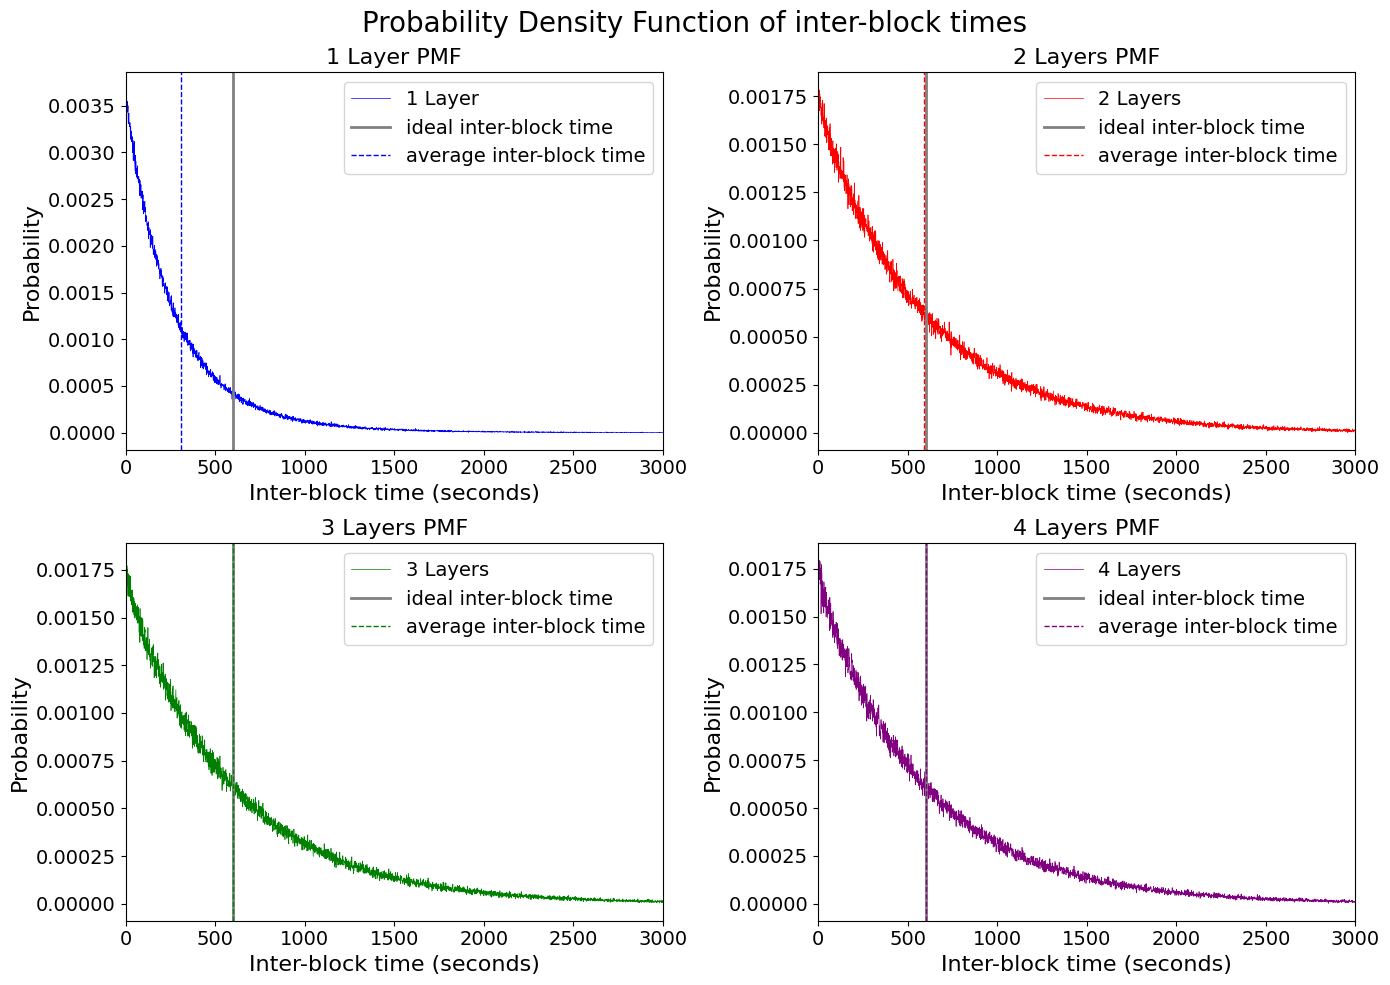

In [25]:
pdf_block_time_1_layer = df_1_layer['block_time'].value_counts(normalize=True).sort_index()
pdf_block_time_2_layer = df_2_layer['block_time'].value_counts(normalize=True).sort_index()
pdf_block_time_3_layer = df_3_layer['block_time'].value_counts(normalize=True).sort_index()
pdf_block_time_4_layer = df_4_layer['block_time'].value_counts(normalize=True).sort_index()

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

axs[0, 0].plot(pdf_block_time_1_layer.index, pdf_block_time_1_layer.values, color='blue', label='1 Layer', linewidth=0.5)
axs[0, 0].axvline(600, color='gray', linestyle='-', linewidth=2, label='ideal inter-block time')
axs[0, 0].axvline(df_1_layer['block_time'].mean(), color='blue', linestyle='--', linewidth=1, label='average inter-block time')
axs[0, 0].set_title('1 Layer PMF', fontsize=16)
axs[0, 0].set_xlabel('Inter-block time (seconds)', fontsize=16)
axs[0, 0].set_ylabel('Probability', fontsize=16)
axs[0, 0].set_xlim(0, 3000)
axs[0, 0].legend(fontsize=14)
axs[0, 0].tick_params(axis='both', which='major', labelsize=14)

axs[0, 1].plot(pdf_block_time_2_layer.index, pdf_block_time_2_layer.values, color='red', label='2 Layers', linewidth=0.5)
axs[0, 1].axvline(600, color='gray', linestyle='-', linewidth=2, label='ideal inter-block time')
axs[0, 1].axvline(df_2_layer['block_time'].mean(), color='red', linestyle='--', linewidth=1, label='average inter-block time')
axs[0, 1].set_title('2 Layers PMF', fontsize=16)
axs[0, 1].set_xlabel('Inter-block time (seconds)', fontsize=16)
axs[0, 1].set_ylabel('Probability', fontsize=16)
axs[0, 1].set_xlim(0, 3000)
axs[0, 1].legend(fontsize=14)
axs[0, 1].tick_params(axis='both', which='major', labelsize=14)

axs[1, 0].plot(pdf_block_time_3_layer.index, pdf_block_time_3_layer.values, color='green', label='3 Layers', linewidth=0.5)
axs[1, 0].axvline(600, color='gray', linestyle='-', linewidth=2, label='ideal inter-block time')
axs[1, 0].axvline(df_3_layer['block_time'].mean(), color='green', linestyle='--', linewidth=1, label='average inter-block time')
axs[1, 0].set_title('3 Layers PMF', fontsize=16)
axs[1, 0].set_xlabel('Inter-block time (seconds)', fontsize=16)
axs[1, 0].set_ylabel('Probability', fontsize=16)
axs[1, 0].set_xlim(0, 3000)
axs[1, 0].legend(fontsize=14)
axs[1, 0].tick_params(axis='both', which='major', labelsize=14)

axs[1, 1].plot(pdf_block_time_4_layer.index, pdf_block_time_4_layer.values, color='purple', label='4 Layers', linewidth=0.5)
axs[1, 1].axvline(600, color='gray', linestyle='-', linewidth=2, label='ideal inter-block time')
axs[1, 1].axvline(df_4_layer['block_time'].mean(), color='purple', linestyle='--', linewidth=1, label='average inter-block time')
axs[1, 1].set_title('4 Layers PMF', fontsize=16)
axs[1, 1].set_xlabel('Inter-block time (seconds)', fontsize=16)
axs[1, 1].set_ylabel('Probability', fontsize=16)
axs[1, 1].set_xlim(0, 3000)
axs[1, 1].legend(fontsize=14)
axs[1, 1].tick_params(axis='both', which='major', labelsize=14)

fig.suptitle('Probability Density Function of inter-block times', fontsize=20)
plt.tight_layout()
plt.show()

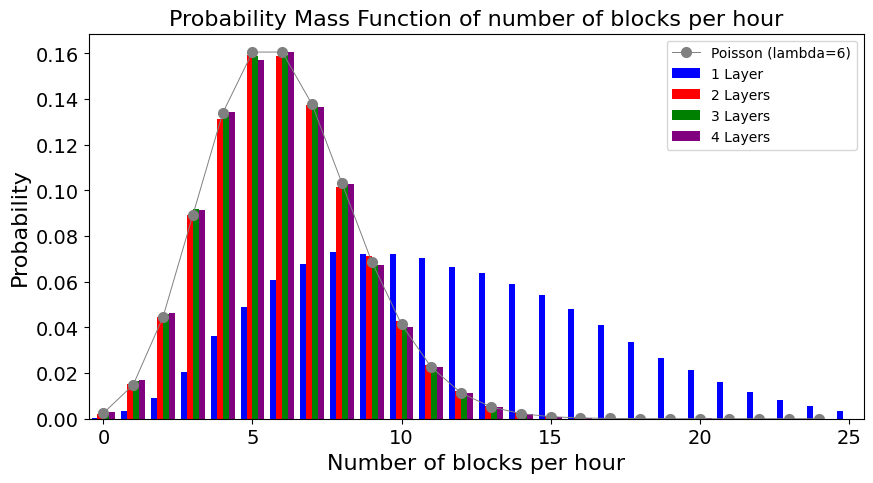

In [26]:
pdf_1_layer = q_res_1_layer_hour_count['record_count'].value_counts(normalize=True).sort_index()
pdf_2_layer = q_res_2_layer_hour_count['record_count'].value_counts(normalize=True).sort_index()
pdf_3_layer = q_res_3_layer_hour_count['record_count'].value_counts(normalize=True).sort_index()
pdf_4_layer = q_res_4_layer_hour_count['record_count'].value_counts(normalize=True).sort_index()


aligned_data_layers = pd.DataFrame({
    '1 Layer': pdf_1_layer,
    '2 Layers': pdf_2_layer,
    '3 Layers': pdf_3_layer,
    '4 Layers': pdf_4_layer
}).fillna(0)

aligned_data_layers = aligned_data_layers[aligned_data_layers.index <= 25]

x_lim = 25
width = 0.2
fig, axs = plt.subplots(1, 1, figsize=(10, 5))
x_positions = np.arange(len(aligned_data_layers))

axs.plot(np.arange(0, x_lim), poisson.pmf(np.arange(0, x_lim), 6), color='gray', label='Poisson (lambda=6)', marker='o', markersize=7, linewidth=0.7)
axs.bar(x_positions - 1.5 * width, aligned_data_layers['1 Layer'].values, width=width, color='blue', label='1 Layer')
axs.bar(x_positions - 0.5 * width, aligned_data_layers['2 Layers'].values, width=width, color='red', label='2 Layers')
axs.bar(x_positions + 0.5 * width, aligned_data_layers['3 Layers'].values, width=width, color='green', label='3 Layers')
axs.bar(x_positions + 1.5 * width, aligned_data_layers['4 Layers'].values, width=width, color='purple', label='4 Layers')

axs.set_xlim(-0.5, len(x_positions) - 0.5)
axs.legend()
axs.set_title('Probability Mass Function of number of blocks per hour', fontsize=16)
axs.set_xlabel('Number of blocks per hour', fontsize=16)
axs.set_ylabel('Probability', fontsize=16)
axs.tick_params(axis='both', which='major', labelsize=14)

tick_positions = np.arange(0, len(aligned_data_layers), 5)
axs.set_xticks(tick_positions)
axs.set_xticklabels(aligned_data_layers.index[tick_positions].astype(int))

plt.show()

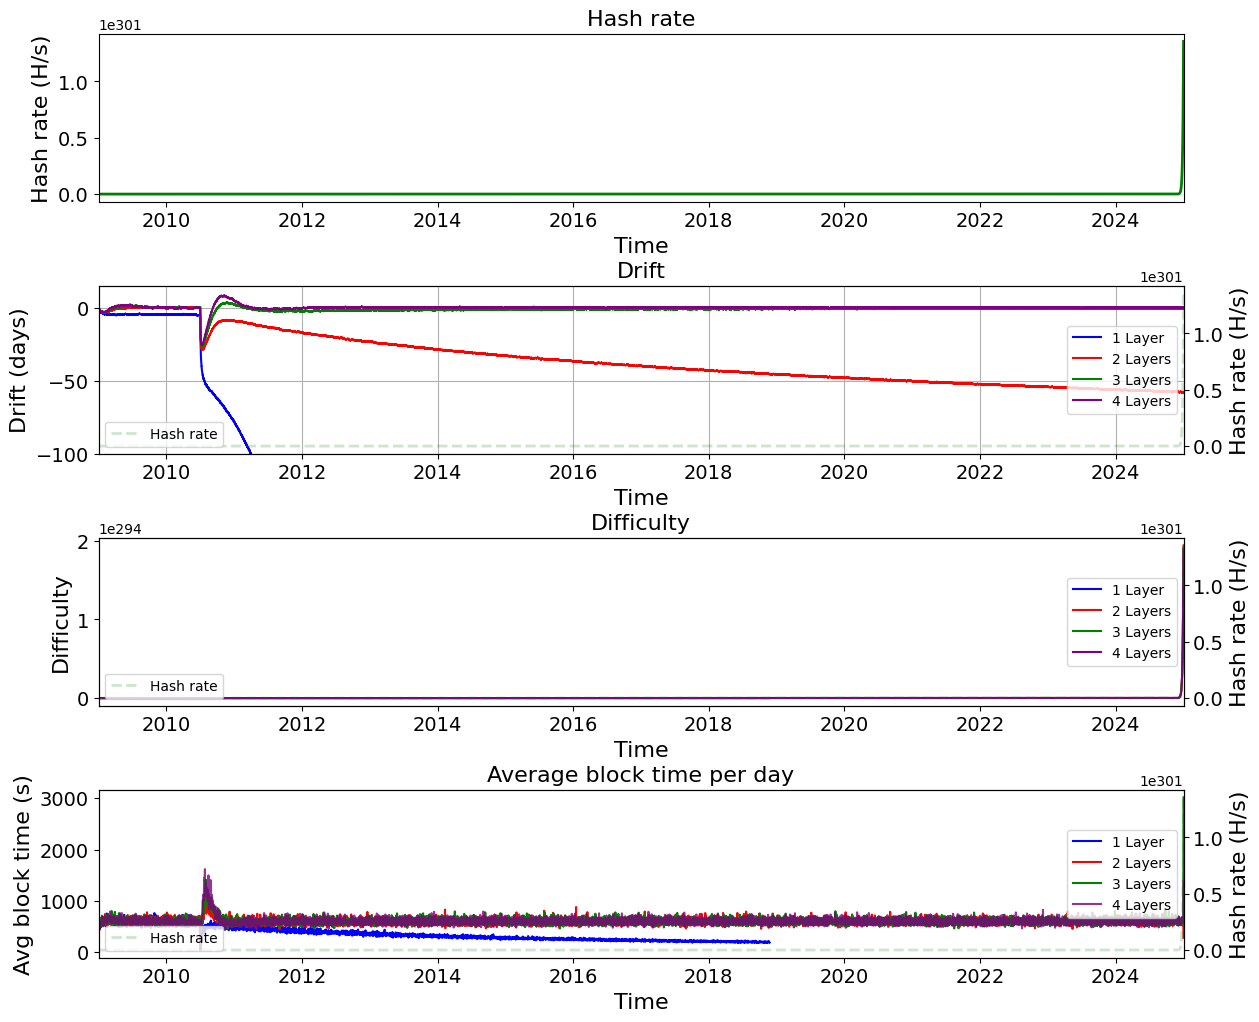

In [27]:
# start_date = pd.Timestamp('2010-07-01')
# end_date = pd.Timestamp('2012-01-01')
start_date = min(df_2_layer['median_time'])
end_date = max(df_2_layer['median_time'])

fig, axs = plt.subplots(4, 1, figsize=(14, 12))

# BE CAREFUL WITH THIS, DIFFERENT LAYERS MAY HAVE DIFFERENT TIME RANGES
axs[0].plot(df_4_layer['median_time'], df_4_layer['real_hash_rate'], color='green', linewidth=2)
axs[0].set_title('Hash rate', fontsize=16)
axs[0].set_xlabel('Time', fontsize=16)
axs[0].set_ylabel('Hash rate (H/s)', fontsize=16)
axs[0].set_xlim(start_date, end_date)
axs[0].tick_params(axis='both', which='major', labelsize=14)

ax2_1 = axs[1].twinx()
ax2_2 = axs[2].twinx()
ax2_3 = axs[3].twinx()

# Plot data on axs[1] and ax2_1
axs[1].plot(df_1_layer['median_time'], df_1_layer['skew'] * 14, color='blue', label='1 Layer')
axs[1].plot(df_2_layer['median_time'], df_2_layer['skew'] * 14, color='red', label='2 Layers')
axs[1].plot(df_3_layer['median_time'], df_3_layer['skew'] * 14, color='green', label='3 Layers')
axs[1].plot(df_4_layer['median_time'], df_4_layer['skew'] * 14, color='purple', label='4 Layers')
axs[1].set_title('Drift', fontsize=16)
axs[1].set_xlabel('Time', fontsize=16)
axs[1].set_ylabel('Drift (days)', fontsize=16)
axs[1].tick_params(axis='both', which='major', labelsize=14)
axs[1].legend(loc='center right')
axs[1].grid()
axs[1].set_xlim(start_date, end_date)
axs[1].set_ylim(-100, 15) # changes the scale of the y-axis
ax2_1.plot(df_4_layer['median_time'], df_4_layer['real_hash_rate'], color='green', label='Hash rate', linestyle='--', alpha=0.2, linewidth=2)
ax2_1.set_ylabel('Hash rate (H/s)', fontsize=16)
ax2_1.tick_params(axis='both', which='major', labelsize=14)
ax2_1.legend(loc='lower left')

# Plot data on axs[2] and ax2_2
axs[2].plot(df_1_layer['median_time'], df_1_layer['difficulty'], color='blue', label='1 Layer')
axs[2].plot(df_2_layer['median_time'], df_2_layer['difficulty'], color='red', label='2 Layers')
axs[2].plot(df_3_layer['median_time'], df_3_layer['difficulty'], color='green', label='3 Layers')
axs[2].plot(df_4_layer['median_time'], df_4_layer['difficulty'], color='purple', label='4 Layers')
axs[2].set_title('Difficulty', fontsize=16)
axs[2].set_xlabel('Time', fontsize=16)
axs[2].set_ylabel('Difficulty', fontsize=16)
axs[2].tick_params(axis='both', which='major', labelsize=14)
axs[2].legend(loc='center right')
axs[2].set_xlim(start_date, end_date)
ax2_2.plot(df_4_layer['median_time'], df_4_layer['real_hash_rate'], color='green', label='Hash rate', linestyle='--', alpha=0.2, linewidth=2)
ax2_2.set_ylabel('Hash rate (H/s)', fontsize=16)
ax2_2.tick_params(axis='both', which='major', labelsize=14)
ax2_2.legend(loc='lower left')

# Plot data on axs[3] and ax2_3
axs[3].plot(q_res_1_layer_avg_block_time['day'], q_res_1_layer_avg_block_time['avg_block_time'], color='blue', label='1 Layer')
axs[3].plot(q_res_2_layer_avg_block_time['day'], q_res_2_layer_avg_block_time['avg_block_time'], color='red', label='2 Layers')
axs[3].plot(q_res_3_layer_avg_block_time['day'], q_res_3_layer_avg_block_time['avg_block_time'], color='green', label='3 Layers')
axs[3].plot(q_res_4_layer_avg_block_time['day'], q_res_4_layer_avg_block_time['avg_block_time'], color='purple', label='4 Layers', alpha=0.8)
axs[3].set_title('Average block time per day', fontsize=16)
axs[3].set_xlabel('Time', fontsize=16)
axs[3].set_ylabel('Avg block time (s)', fontsize=16)
axs[3].tick_params(axis='both', which='major', labelsize=14)
axs[3].legend(loc='center right')
axs[3].set_xlim(start_date, end_date)
ax2_3.plot(df_4_layer['median_time'], df_4_layer['real_hash_rate'], color='green', label='Hash rate', linestyle='--', alpha=0.2, linewidth=2)
ax2_3.set_ylabel('Hash rate (H/s)', fontsize=16)
ax2_3.tick_params(axis='both', which='major', labelsize=14)
ax2_3.legend(loc='lower left')

plt.subplots_adjust(hspace=0.5)
plt.show()

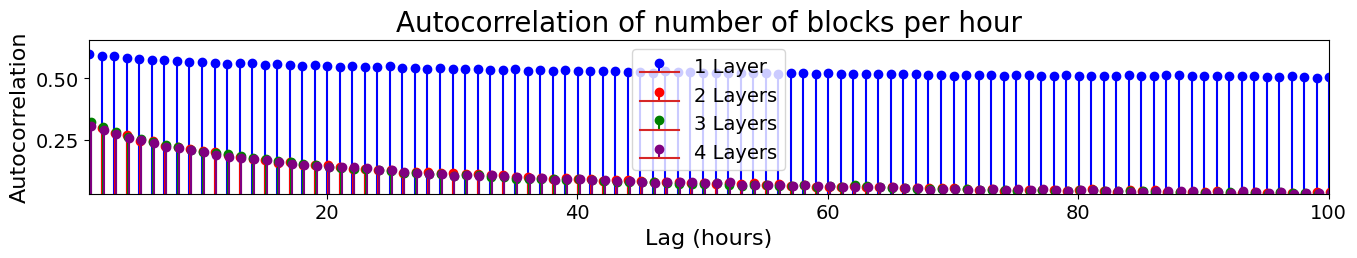

In [28]:
x_lim = 100

acf_values_1_layer = acf(q_res_1_layer_hour_count['record_count'], nlags=x_lim)
acf_values_2_layer = acf(q_res_2_layer_hour_count['record_count'], nlags=x_lim)
acf_values_3_layer = acf(q_res_3_layer_hour_count['record_count'], nlags=x_lim)
acf_values_4_layer = acf(q_res_4_layer_hour_count['record_count'], nlags=x_lim)

lags = np.arange(0, x_lim + 1)
width = 0.2
plt.stem(lags + 0.25 * width, acf_values_1_layer, label='1 Layer', linefmt='blue')
plt.stem(lags + 0.5 * width, acf_values_2_layer, label='2 Layers', linefmt='red')
plt.stem(lags + 0.75 * width, acf_values_3_layer, label='3 Layers', linefmt='green')
plt.stem(lags + width, acf_values_4_layer, label='4 Layers', linefmt='purple')
plt.title('Autocorrelation of number of blocks per hour', fontsize=20)
plt.xlabel('Lag (hours)', fontsize=16)
plt.ylabel('Autocorrelation', fontsize=16)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.gcf().set_size_inches(16, 2)
plt.legend(fontsize=14)
plt.ylim(min(min(acf_values_1_layer[1:]), min(acf_values_2_layer[1:]), min(acf_values_3_layer[1:]), min(acf_values_4_layer[1:])) * 1.1, 
         max(max(acf_values_1_layer[1:]), max(acf_values_2_layer[1:]), max(acf_values_3_layer[1:]), max(acf_values_4_layer[1:])) * 1.1)
plt.xlim(1, x_lim)
plt.show()

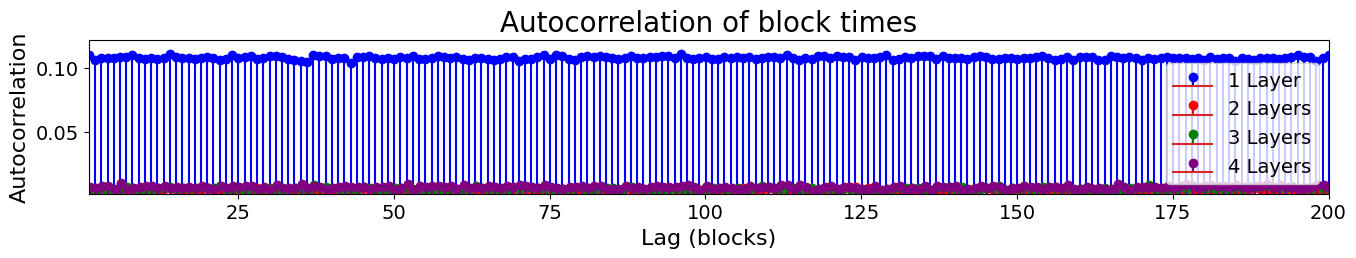

In [29]:
x_lim = 200

acf_values_1_layer = acf(df_1_layer['block_time'], nlags=x_lim)
acf_values_2_layer = acf(df_2_layer['block_time'], nlags=x_lim)
acf_values_3_layer = acf(df_3_layer['block_time'], nlags=x_lim)
acf_values_4_layer = acf(df_4_layer['block_time'], nlags=x_lim)

lags = np.arange(0, x_lim + 1)
width = 0.2
plt.stem(lags + 0.25 * width, acf_values_1_layer, label='1 Layer', linefmt='blue')
plt.stem(lags + 0.5 * width, acf_values_2_layer, label='2 Layers', linefmt='red')
plt.stem(lags + 0.75 * width, acf_values_3_layer, label='3 Layers', linefmt='green')
plt.stem(lags + width, acf_values_4_layer, label='4 Layers', linefmt='purple')
plt.title('Autocorrelation of block times', fontsize=20)
plt.xlabel('Lag (blocks)', fontsize=16)
plt.ylabel('Autocorrelation', fontsize=16)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.gcf().set_size_inches(16, 2)
plt.legend(fontsize=14, loc='lower right')
plt.ylim(min(min(acf_values_1_layer[1:]), min(acf_values_2_layer[1:]), min(acf_values_3_layer[1:]), min(acf_values_4_layer[1:])) * 1.1, 
         max(max(acf_values_1_layer[1:]), max(acf_values_2_layer[1:]), max(acf_values_3_layer[1:]), max(acf_values_4_layer[1:])) * 1.1)
plt.xlim(1, x_lim)
plt.show()